In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# 1) Load & basic features

df = pd.read_csv("merged_mpu_data_all.csv")
df["mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

X = df[["ax", "ay", "az", "mag"]].values

le = LabelEncoder()
y = le.fit_transform(df["label"])
class_names = le.classes_


# 2) Split: train/val/test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# 3) Scale cho các model cầ
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

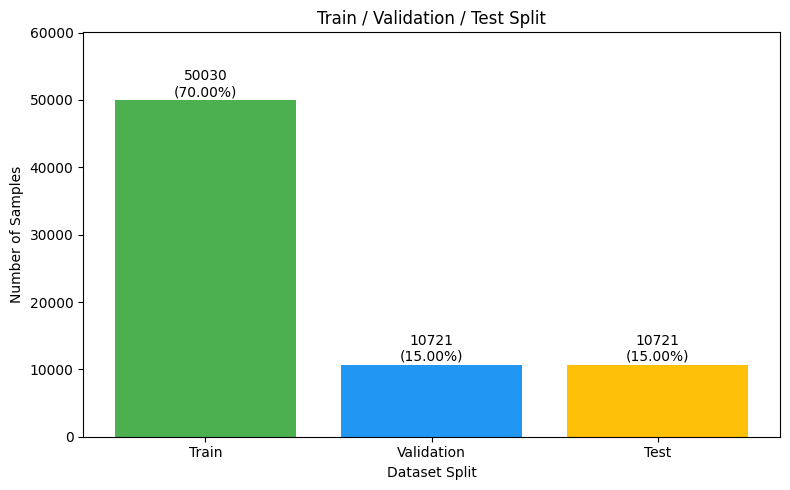

In [ ]:
# Visualize train/val/test split (compact version)
split_counts = {'Train': len(y_train), 'Validation': len(y_val), 'Test': len(y_test)}
total = sum(split_counts.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(split_counts.keys(), split_counts.values(), color=['#4CAF50', '#2196F3', '#FFC107'])
plt.title("Train / Validation / Test Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.ylim(0, max(split_counts.values()) * 1.2)

for bar, (name, count) in zip(bars, split_counts.items()):
    pct = count / total * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{count}\n({pct:.2f}%)", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


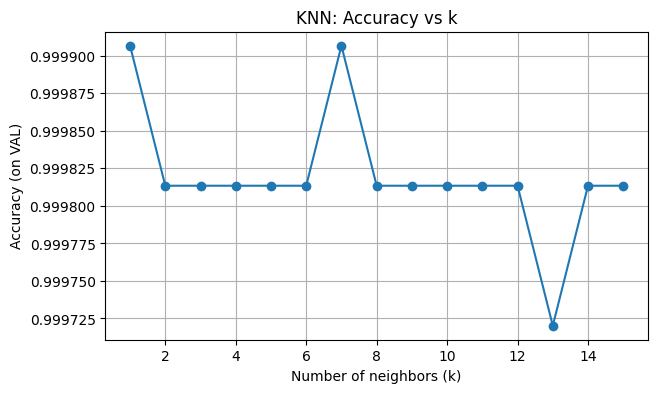

[Tuning] Best k for KNN = 1


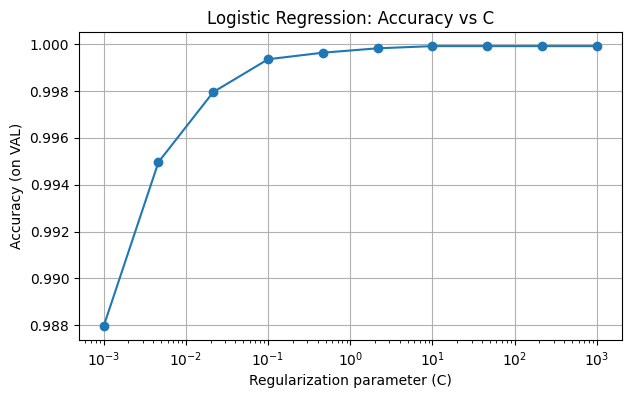

[Tuning] Best C for Logistic Regression = 10.0000


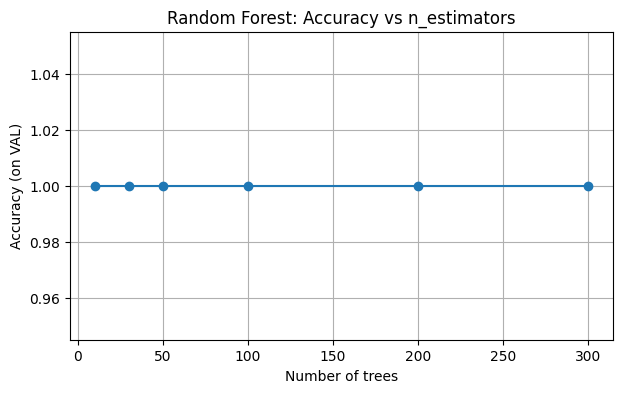

[Tuning] Best n_estimators for RF = 10


In [ ]:
# 4) Chọn siêu tham số trên VAL
# 4.1 KNN: chọn k theo Accuracy trên VAL
k_values = range(1, 16)
acc_knn = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    pred = knn.predict(X_val_s)
    acc_knn.append(accuracy_score(y_val, pred))
best_k = k_values[int(np.argmax(acc_knn))]

plt.figure(figsize=(7,4))
plt.plot(k_values, acc_knn, marker='o')
plt.title("KNN: Accuracy vs k")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy (on VAL)")
plt.grid(True)
plt.show()
print(f"[Tuning] Best k for KNN = {best_k}")

# 4.2 Logistic Regression: chọn C theo Accuracy trên VAL
C_values = np.logspace(-3, 3, 10)
acc_log = []
for c in C_values:
    log_reg = LogisticRegression(C=c, max_iter=2000, solver='lbfgs')
    log_reg.fit(X_train_s, y_train)
    pred = log_reg.predict(X_val_s)
    acc_log.append(accuracy_score(y_val, pred))
best_C = C_values[int(np.argmax(acc_log))]

plt.figure(figsize=(7,4))
plt.semilogx(C_values, acc_log, marker='o')
plt.title("Logistic Regression: Accuracy vs C")
plt.xlabel("Regularization parameter (C)")
plt.ylabel("Accuracy (on VAL)")
plt.grid(True)
plt.show()
print(f"[Tuning] Best C for Logistic Regression = {best_C:.4f}")

# 4.3 Random Forest: chọn n_estimators theo Accuracy trên VAL
n_estimators_list = [10, 30, 50, 100, 200, 300]
acc_rf = []
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, class_weight="balanced")
    rf.fit(X_train, y_train)  # RF không cần scale
    pred = rf.predict(X_val)
    acc_rf.append(accuracy_score(y_val, pred))
best_n = n_estimators_list[int(np.argmax(acc_rf))]

plt.figure(figsize=(7,4))
plt.plot(n_estimators_list, acc_rf, marker='o')
plt.title("Random Forest: Accuracy vs n_estimators")
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (on VAL)")
plt.grid(True)
plt.show()
print(f"[Tuning] Best n_estimators for RF = {best_n}")

In [ ]:
# 5) Refit FINAL trên TRAIN+VAL với siêu tham số tốt nhất

# KNN/LogReg dùng bản đã scale
X_trval_s = np.vstack([X_train_s, X_val_s])
y_trval   = np.concatenate([y_train, y_val])

best_knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_trval_s, y_trval)
best_log = LogisticRegression(C=best_C, max_iter=2000).fit(X_trval_s, y_trval)

# RF dùng bản raw (không scale)
X_trval   = np.vstack([X_train, X_val])
y_trval_rf = y_trval  # cùng nhãn
best_rf  = RandomForestClassifier(
    n_estimators=best_n, random_state=42, class_weight="balanced"
).fit(X_trval, y_trval_rf)

models = {
    "KNN": (best_knn, X_test_s),
    "Logistic Regression": (best_log, X_test_s),
    "Random Forest": (best_rf, X_test),
}

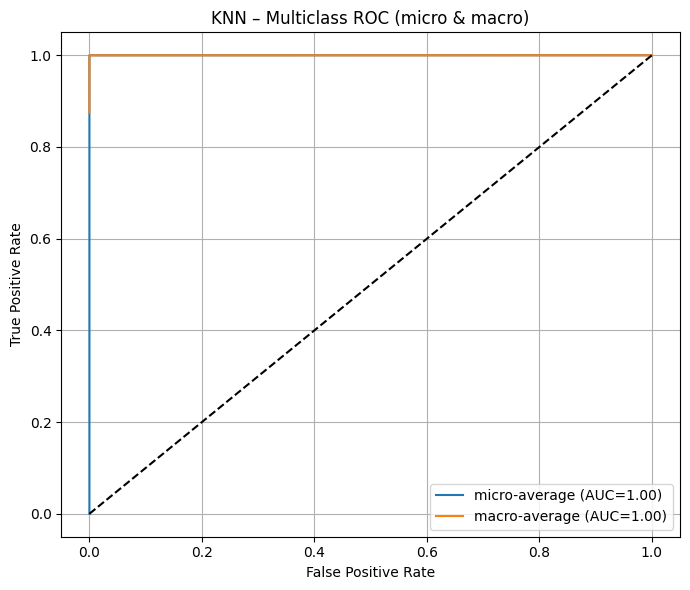

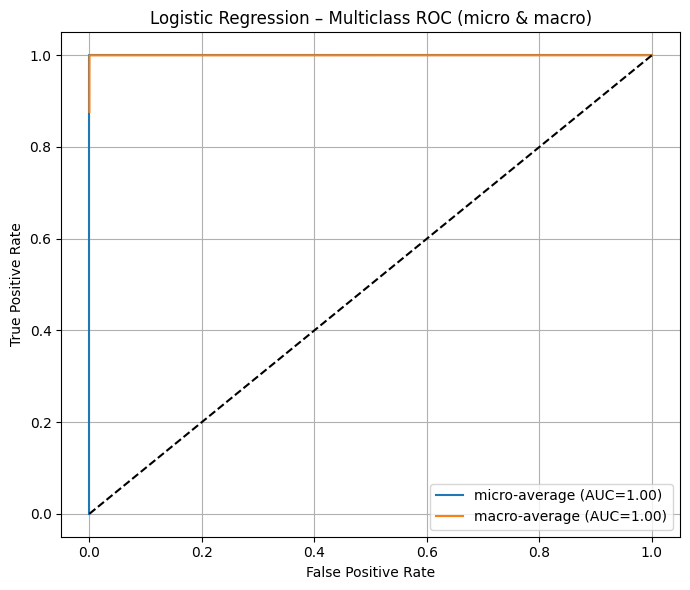

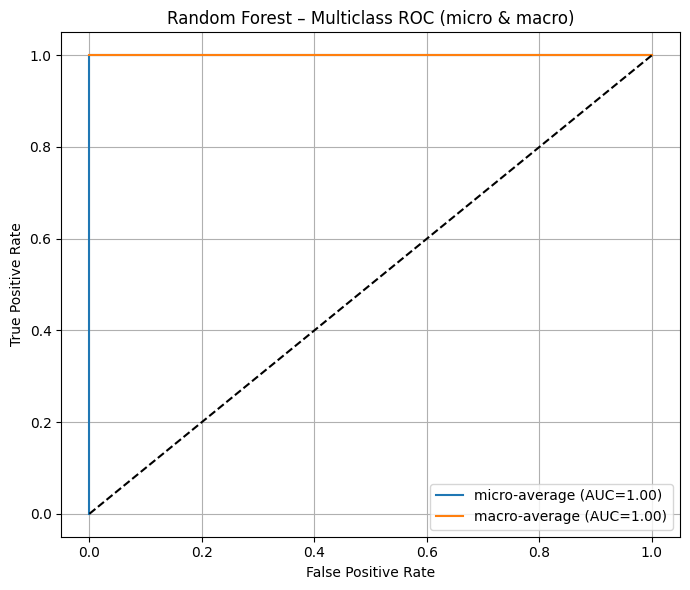

In [ ]:
# 6) ROC (micro/macro)

classes_idx = np.arange(len(class_names))
Y_test_bin = label_binarize(y_test, classes=classes_idx)

def proba_aligned(model, proba, classes_idx):
    """
    Căn chỉnh cột xác suất của predict_proba theo đúng thứ tự lớp
    (0..K-1). model.classes_ là thứ tự cột hiện tại.
    """
    order = [int(np.where(model.classes_ == c)[0][0]) for c in classes_idx]
    return proba[:, order]

def plot_multiclass_roc(model, X_t, title):
    proba_raw = model.predict_proba(X_t)  # (n_samples, n_classes_in_model)
    proba = proba_aligned(model, proba_raw, classes_idx)

    # Per-class ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(classes_idx)):
        fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro
    fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro (interpolate)
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes_idx))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes_idx)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes_idx)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot
    plt.figure(figsize=(7,6))
    plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average (AUC={roc_auc['micro']:.2f})")
    plt.plot(fpr["macro"], tpr["macro"], label=f"macro-average (AUC={roc_auc['macro']:.2f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Gọi cho từng model
for name, (model, X_t) in models.items():
    plot_multiclass_roc(model, X_t, f"{name} – Multiclass ROC (micro & macro)")


==================== KNN ====================
Classification report:
              precision    recall  f1-score   support

        left     1.0000    1.0000    1.0000       861
       prone     0.9988    1.0000    0.9994       859
  prone_left     1.0000    1.0000    1.0000      1806
 prone_right     1.0000    1.0000    1.0000      1803
       right     1.0000    0.9989    0.9994       904
      supine     1.0000    1.0000    1.0000       861
 supine_left     1.0000    1.0000    1.0000      1820
supine_right     1.0000    1.0000    1.0000      1807

    accuracy                         0.9999     10721
   macro avg     0.9999    0.9999    0.9999     10721
weighted avg     0.9999    0.9999    0.9999     10721



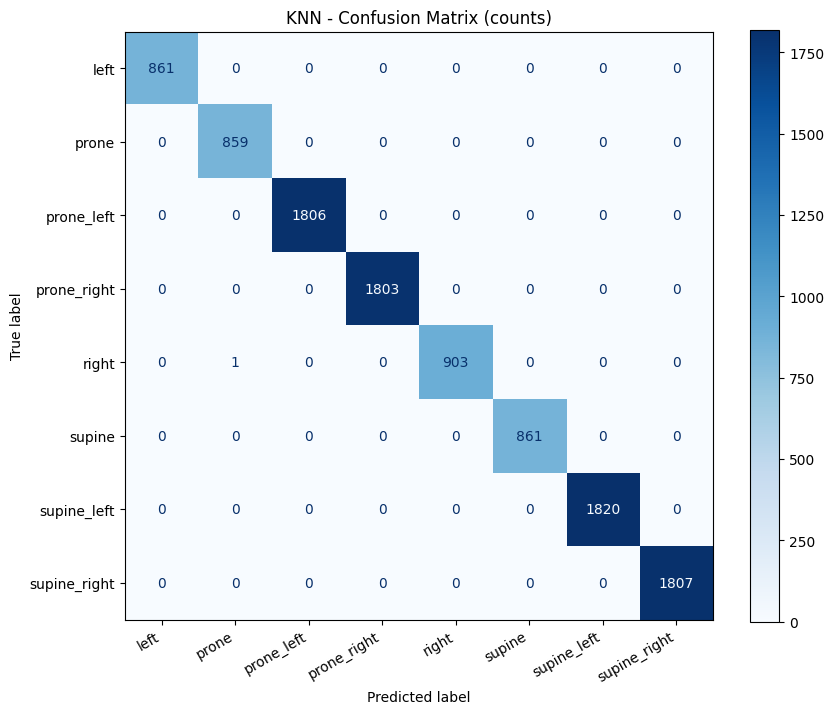

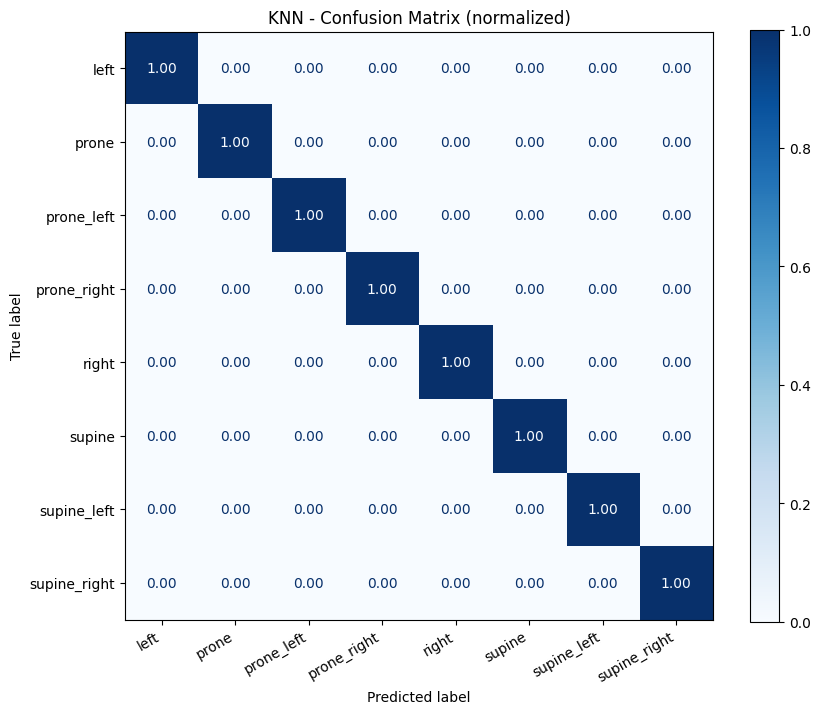


==================== Logistic Regression ====================
Classification report:
              precision    recall  f1-score   support

        left     1.0000    1.0000    1.0000       861
       prone     1.0000    1.0000    1.0000       859
  prone_left     1.0000    1.0000    1.0000      1806
 prone_right     0.9994    1.0000    0.9997      1803
       right     1.0000    0.9989    0.9994       904
      supine     1.0000    0.9988    0.9994       861
 supine_left     1.0000    1.0000    1.0000      1820
supine_right     0.9994    1.0000    0.9997      1807

    accuracy                         0.9998     10721
   macro avg     0.9999    0.9997    0.9998     10721
weighted avg     0.9998    0.9998    0.9998     10721



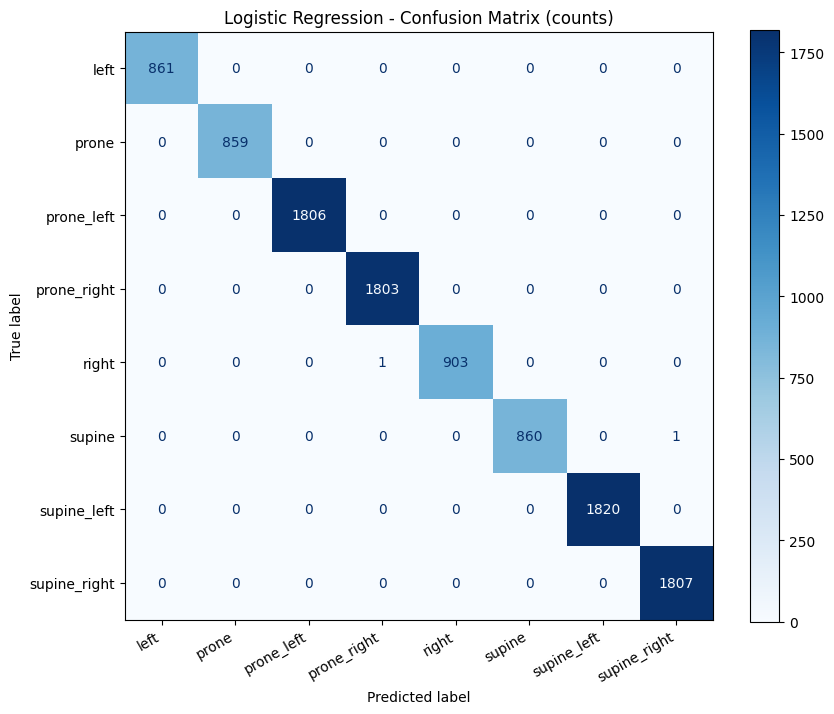

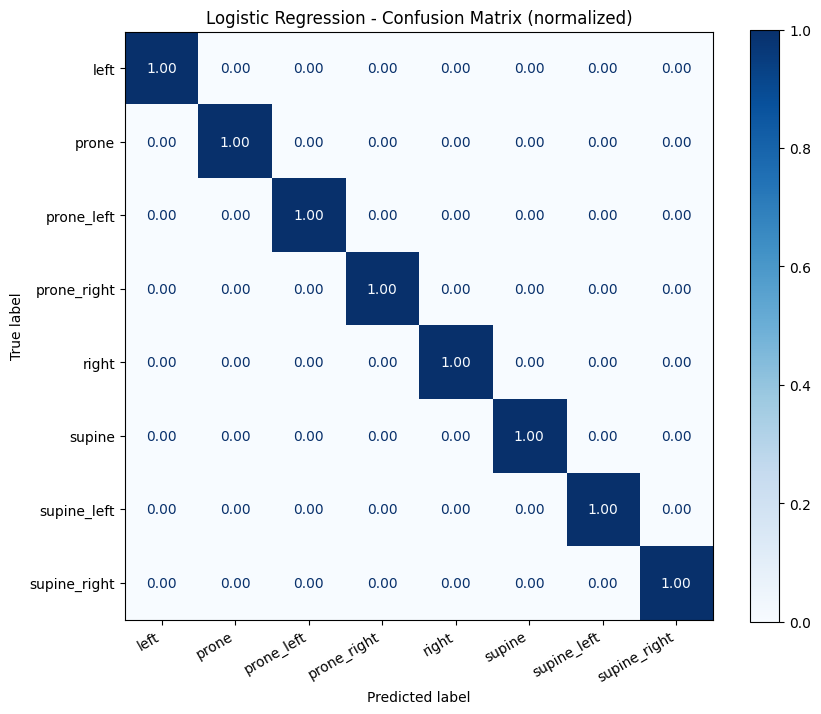


==================== Random Forest ====================
Classification report:
              precision    recall  f1-score   support

        left     1.0000    1.0000    1.0000       861
       prone     1.0000    1.0000    1.0000       859
  prone_left     1.0000    1.0000    1.0000      1806
 prone_right     1.0000    1.0000    1.0000      1803
       right     1.0000    1.0000    1.0000       904
      supine     1.0000    1.0000    1.0000       861
 supine_left     1.0000    1.0000    1.0000      1820
supine_right     1.0000    1.0000    1.0000      1807

    accuracy                         1.0000     10721
   macro avg     1.0000    1.0000    1.0000     10721
weighted avg     1.0000    1.0000    1.0000     10721



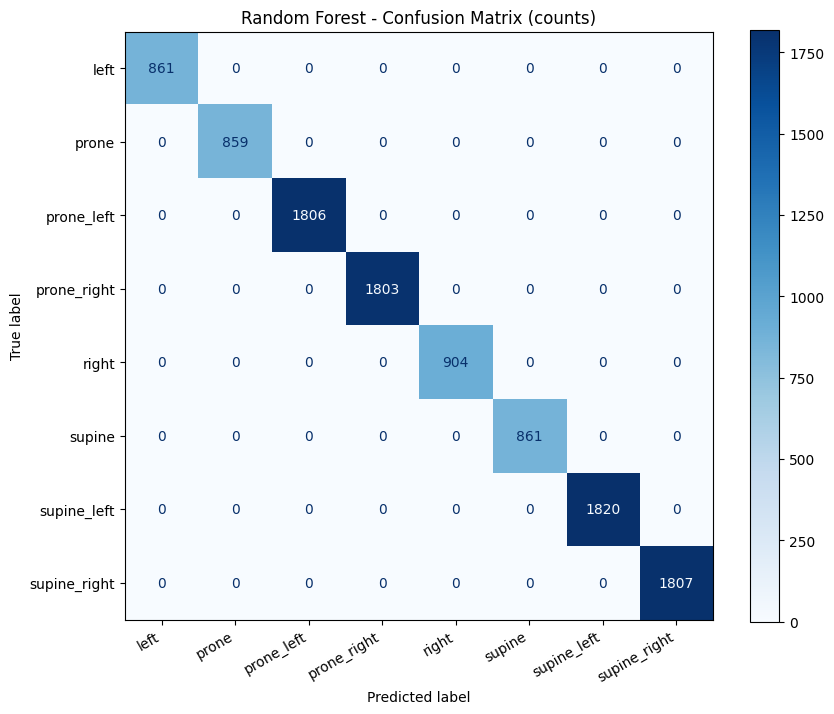

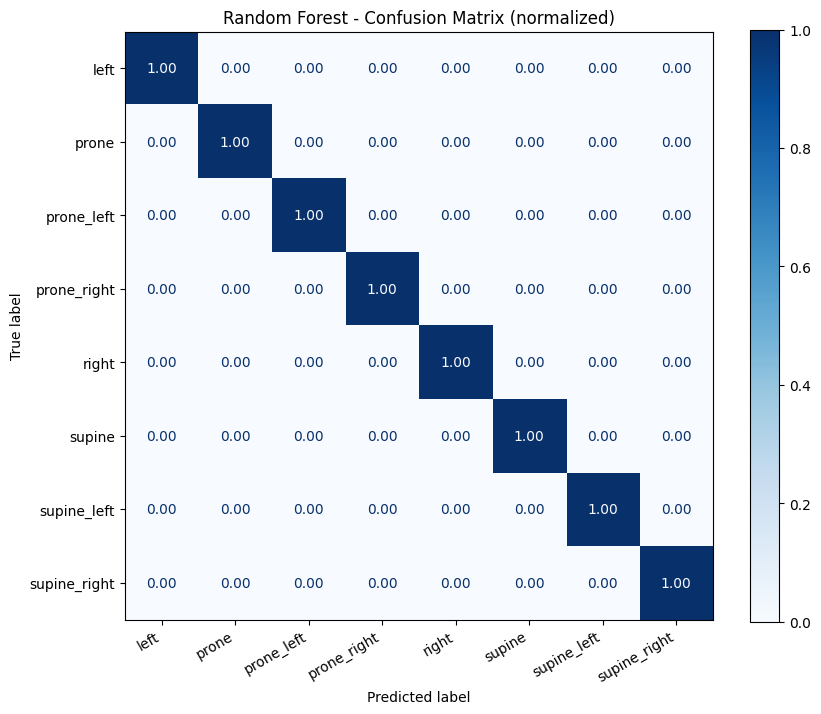

In [ ]:
# 7) Reports & Confusion Matrices

for name, (model, X_t) in models.items():
    print(f"\n{'='*20} {name} {'='*20}")
    pred = model.predict(X_t)

    # classification_report
    print("Classification report:")
    print(classification_report(y_test, pred, target_names=class_names, digits=4))

    # Confusion matrix (đếm)
    cm = confusion_matrix(y_test, pred, labels=classes_idx)
    fig, ax = plt.subplots(
        figsize=(max(8, 1.1*len(class_names)), max(6, 0.9*len(class_names)))
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(include_values=True, cmap="Blues", ax=ax, colorbar=True, values_format="d")
    ax.set_title(f"{name} - Confusion Matrix (counts)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # Confusion matrix (chuẩn hóa)
    cm_norm = confusion_matrix(y_test, pred, labels=classes_idx, normalize="true")
    fig, ax = plt.subplots(
        figsize=(max(8, 1.1*len(class_names)), max(6, 0.9*len(class_names)))
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(include_values=True, cmap="Blues", ax=ax, colorbar=True, values_format=".2f")
    ax.set_title(f"{name} - Confusion Matrix (normalized)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()



Comparison table:
                  Model  Accuracy  ROC-AUC (macro)  ROC-AUC (weighted)
0                  KNN  0.999907         0.999925            0.999949
1  Logistic Regression  0.999813         0.999940            0.999950
2        Random Forest  1.000000         1.000000            1.000000


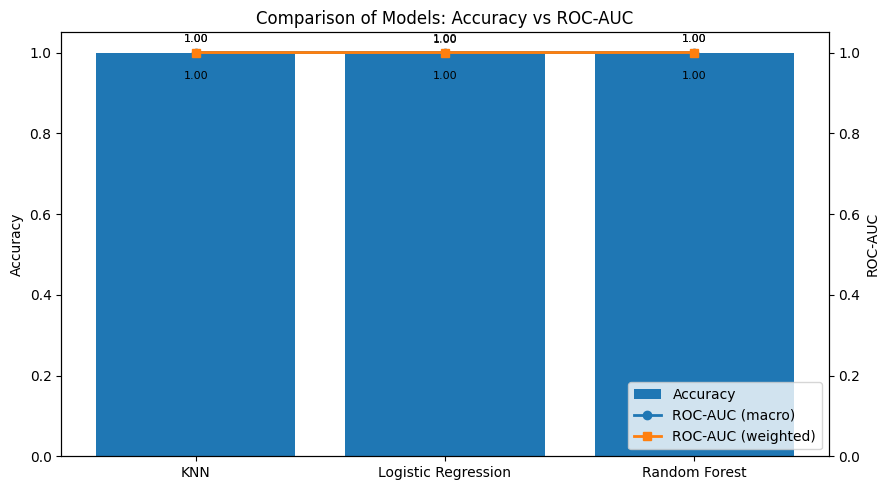

In [ ]:
# 8) Tổng hợp Accuracy & AUC (ovr)

rows = []
for name, (model, X_t) in models.items():
    pred = model.predict(X_t)

    proba_raw = model.predict_proba(X_t)
    proba = proba_aligned(model, proba_raw, classes_idx)

    acc = accuracy_score(y_test, pred)
    try:
        # AUC đa lớp one-vs-rest; có thể thêm average="weighted" nếu lệch lớp
        auc_val = roc_auc_score(y_test, proba, multi_class="ovr")
        auc_weighted = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")
    except Exception:
        auc_val = np.nan
        auc_weighted = np.nan

    rows.append([name, acc, auc_val, auc_weighted])

df_results = pd.DataFrame(rows, columns=["Model", "Accuracy", "ROC-AUC (macro)", "ROC-AUC (weighted)"])
print("\nComparison table:\n", df_results)

# Biểu đồ: cột Accuracy + line AUC macro/weighted
fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(df_results["Model"], df_results["Accuracy"], label="Accuracy")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)

# Hiển thị giá trị trên cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}",
             ha="center", va="bottom", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(df_results["Model"], df_results["ROC-AUC (macro)"], marker="o", linewidth=2, label="ROC-AUC (macro)")
ax2.plot(df_results["Model"], df_results["ROC-AUC (weighted)"], marker="s", linewidth=2, label="ROC-AUC (weighted)")
ax2.set_ylabel("ROC-AUC")
ax2.set_ylim(0, 1.05)

# Hiển thị giá trị trên điểm
for i, val in enumerate(df_results["ROC-AUC (macro)"]):
    ax2.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=8)
for i, val in enumerate(df_results["ROC-AUC (weighted)"]):
    ax2.text(i, val - 0.07, f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Legend gộp 2 trục
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="lower right")

plt.title("Comparison of Models: Accuracy vs ROC-AUC")
plt.tight_layout()
plt.show()